<a href="https://colab.research.google.com/github/NMa-na-sa/Neural-networks-and-deep-learning/blob/main/Experiment-2/Experiment_2_MSE_vs_BCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model A (MSE)
Loss: 0.07067166268825531
Accuracy: 0.9200000166893005

Model B (BCE)
Loss: 0.12144942581653595
Accuracy: 0.9599999785423279


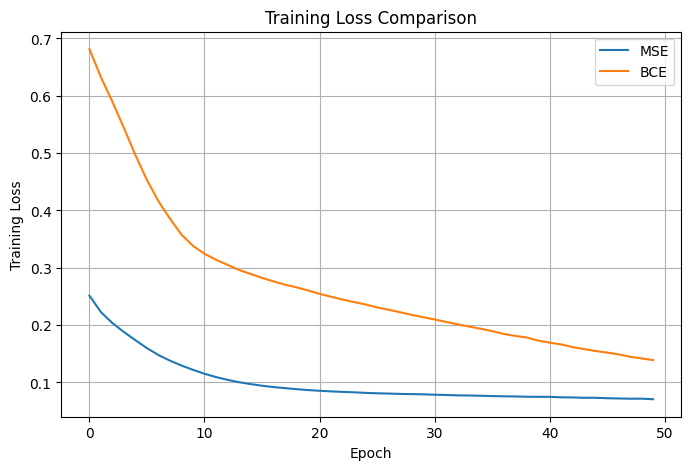

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Function to build model
def build_model(loss):
    model = Sequential([
        Dense(16, activation='relu', input_shape=(2,)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss=loss,
        metrics=['accuracy']
    )
    return model

# Model A (MSE)
model_mse = build_model('mse')

# Model B (BCE)
model_bce = build_model('binary_crossentropy')

history_mse = model_mse.fit(
    X_train,
    y_train,
    epochs=50,
    verbose=0,
    validation_data=(X_test,y_test)
)

history_bce = model_bce.fit(
    X_train,
    y_train,
    epochs=50,
    verbose=0,
    validation_data=(X_test,y_test)
)

# Evaluation
mse_loss, mse_acc = model_mse.evaluate(X_test,y_test,verbose=0)
bce_loss, bce_acc = model_bce.evaluate(X_test,y_test,verbose=0)

print("Model A (MSE)")
print("Loss:", mse_loss)
print("Accuracy:", mse_acc)

print()

print("Model B (BCE)")
print("Loss:", bce_loss)
print("Accuracy:", bce_acc)

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history_mse.history['loss'], label='MSE')
plt.plot(history_bce.history['loss'], label='BCE')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()